# Gold Code Generator

Authors:

Jan Bartnik

Ksawery Broszkiewicz

## 1. Introduction
Gold codes are a special class of pseudorandom sequences whose cross-correlation properties make them highly suitable for use in spread spectrum telecommunication systems. They are widely utilized in technologies such as CDMA (Code Division Multiple Access) and global satellite navigation systems like GPS.

The primary advantage of Gold codes over standard m-sequences is that they provide a much larger set of sequences with bounded, predictable, and low cross-correlation values. This allows multiple users to transmit data over the same frequency band simultaneously without severe interference.

## 2. Mathematical Background

### Linear Feedback Shift Registers (LFSR)
The fundamental building block of a Gold code generator is the Linear Feedback Shift Register. An LFSR generates a pseudorandom sequence based on a characteristic polynomial over the Galois Field GF(2):
$$P(x) = x^n + c_{n-1}x^{n-1} + \dots + c_1x + 1$$
Where the coefficients $c_i \in \{0, 1\}$ represent the tap connections. If $P(x)$ is a primitive polynomial, the LFSR generates a maximum-length sequence (m-sequence) of length $N = 2^n - 1$.

### Gold Code Construction
A Gold sequence $g(t)$ is generated by performing a bitwise modulo-2 addition (XOR) of two distinct m-sequences, $a(t)$ and $b(t)$, of the same length $N$:
$$g(t) = a(t) \oplus b(t + \tau)$$
Here, $\tau$ represents the phase shift, which is determined by the initial states (seeds) of the two LFSRs. The m-sequences must form a *preferred pair* to guarantee the minimal cross-correlation properties defined by Robert Gold's theorem.

## 3. Algorithm Implementation

The following Python implementation defines the LFSR step and the combination of two sequences to produce the Gold code.

In [11]:
def lfsr_step(state, taps):
    feedback = 0
    for tap in taps:
        feedback ^= state[tap]
    out_bit = state[-1]
    new_state = [feedback] + state[:-1]
    return out_bit, new_state

def gold_code_generator(seed1, taps1, seed2, taps2, length):
    state1 = seed1.copy()
    state2 = seed2.copy()
    sequence = []
    for _ in range(length):
        out1, state1 = lfsr_step(state1, taps1)
        out2, state2 = lfsr_step(state2, taps2)
        sequence.append(out1 ^ out2)
    return sequence

## 4. Algorithm flowchart

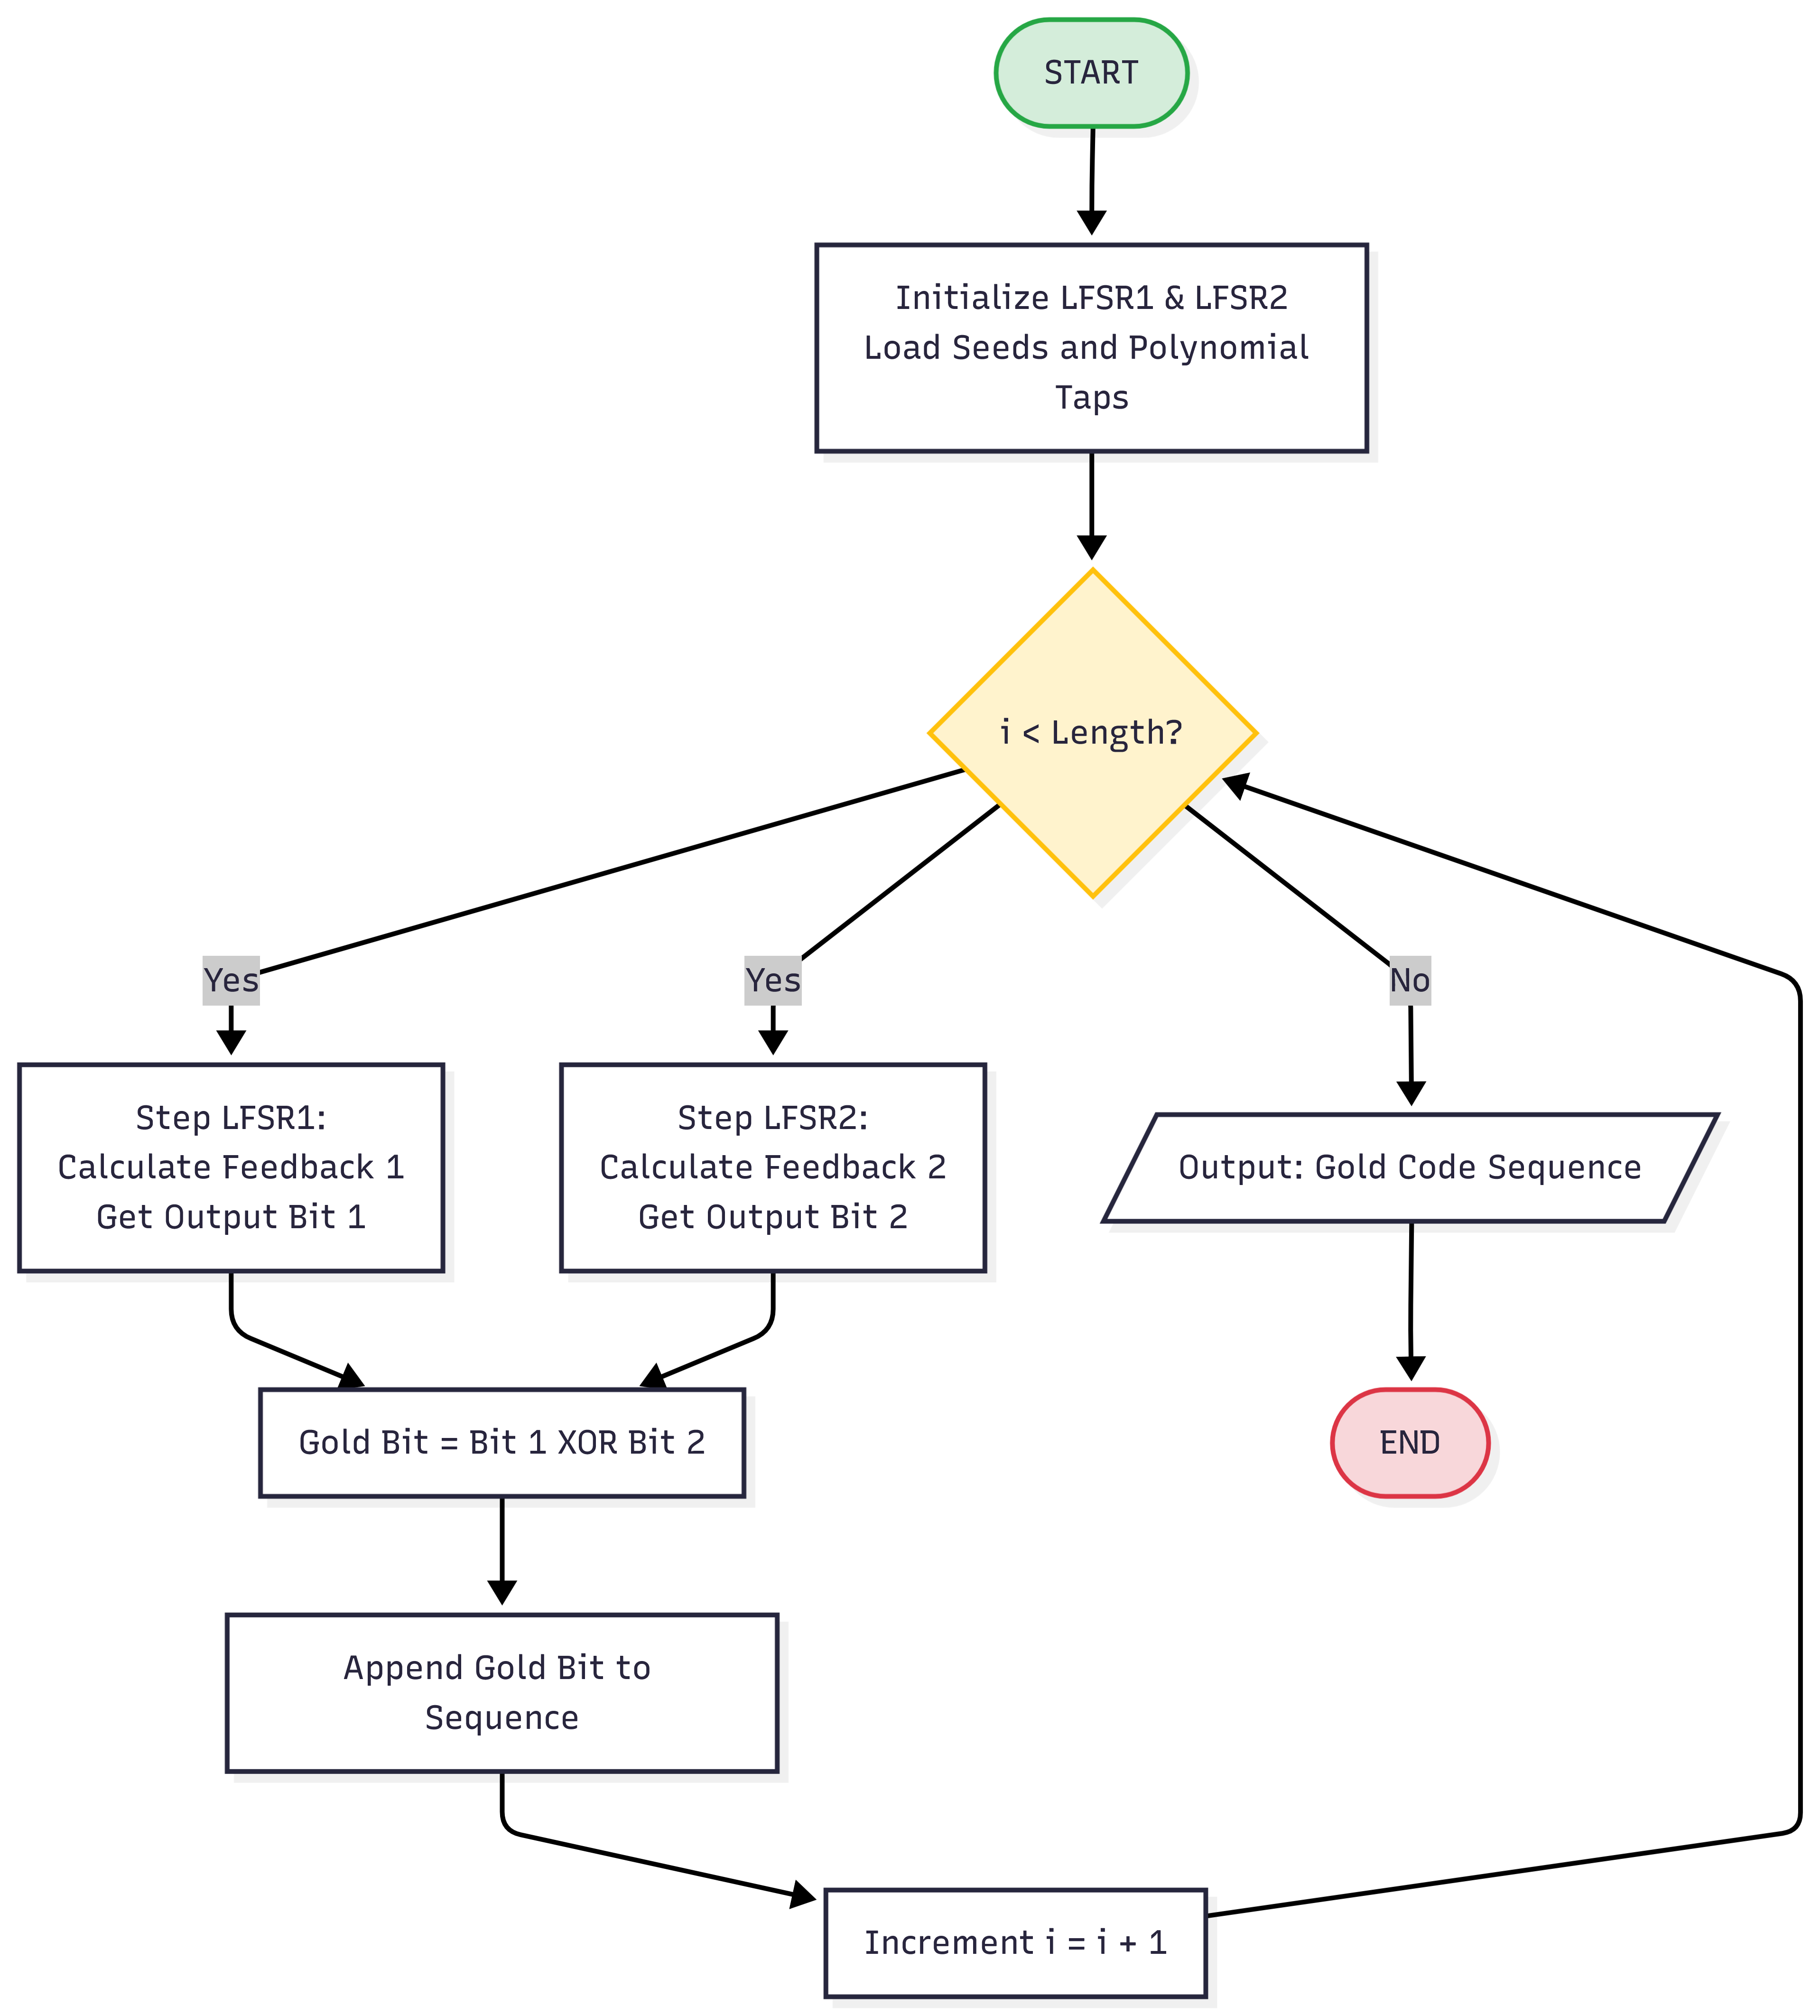

In [9]:
from IPython.display import Image, display
display(Image(filename='/content/Gold_Code_Flowchart.png', width=800))

## 5. Sequence Generation and Verification

To verify the algorithm, we instantiate two 5-bit LFSRs with specific tap configurations and seeds. The length of the generated sequence is set to $2^5 - 1 = 31$, which corresponds to the full period of the m-sequences.

In [12]:
seed_a = [1, 0, 1, 1, 0]
taps_a = [1, 4]
seed_b = [0, 1, 1, 0, 1]
taps_b = [2, 4]

gold_sequence = gold_code_generator(seed_a, taps_a, seed_b, taps_b, 31)
print(gold_sequence)

[1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0]


## 6. Cross-Correlation Analysis

One of the defining features of Gold codes is their bounded cross-correlation. For a preferred pair of m-sequences of length $N = 2^n - 1$, the cross-correlation values are restricted to a three-valued spectrum. This script computes the cyclic cross-correlation of sequences to demonstrate this property.

In [13]:
def calculate_cross_correlation(seq1, seq2):
    length = len(seq1)
    correlation = []
    for shift in range(length):
        corr_val = 0
        for i in range(length):
            bit1 = 1 if seq1[i] == 0 else -1
            bit2 = 1 if seq2[(i + shift) % length] == 0 else -1
            corr_val += bit1 * bit2
        correlation.append(corr_val)
    return correlation

cross_corr = calculate_cross_correlation(gold_sequence, gold_sequence)
print(cross_corr)

[31, -9, -5, 3, 3, -5, 7, -1, 3, -1, -1, 3, 3, -9, 3, 3, 3, 3, -9, 3, 3, -1, -1, 3, -1, 7, -5, 3, 3, -5, -9]
